Exploratory Data Analysis 

In [2]:
#Basic inspection
import pandas as pd


df = pd.read_csv("/home/vaidehi-deogade/Desktop/Konverge/Projects/olist_ml_analytics/raw_data/processed_data/cleaned_dataset.csv")

# Basic overview with helpful labels
print("Shape of the dataset:", df.shape)

Shape of the dataset: (117294, 41)


In [3]:
print("General Information:")
df.info()

General Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117294 entries, 0 to 117293
Data columns (total 41 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Unnamed: 0                     117294 non-null  int64  
 1   order_id                       117294 non-null  object 
 2   customer_id                    117294 non-null  object 
 3   order_status                   117294 non-null  object 
 4   order_purchase_timestamp       117294 non-null  object 
 5   order_approved_at              117294 non-null  object 
 6   order_delivered_carrier_date   116059 non-null  object 
 7   order_delivered_customer_date  114823 non-null  object 
 8   order_estimated_delivery_date  117294 non-null  object 
 9   order_item_id                  117294 non-null  float64
 10  product_id                     117294 non-null  object 
 11  seller_id                      117294 non-null  object 
 12  shipping_

In [4]:
print("Statistical Summary:",df.describe())


Statistical Summary:           Unnamed: 0  order_item_id          price  freight_value  \
count  117294.000000  117294.000000  117294.000000  117294.000000   
mean    59548.967518       1.194153     120.524288      20.028474   
std     34400.623563       0.684307     182.888620      15.830022   
min         0.000000       1.000000       0.850000       0.000000   
25%     29734.250000       1.000000      39.900000      13.080000   
50%     59574.500000       1.000000      74.900000      16.280000   
75%     89344.750000       1.000000     134.900000      21.180000   
max    119142.000000      21.000000    6735.000000     409.680000   

       product_name_lenght  product_description_lenght  product_photos_qty  \
count        115619.000000               115619.000000       115619.000000   
mean             48.767322                  785.804011            2.205632   
std              10.033866                  652.411543            1.717851   
min               5.000000                   

In [5]:
print("First 5 Rows:",df.head())


First 5 Rows:    Unnamed: 0                          order_id  \
0           0  e481f51cbdc54678b7cc49136f2d6af7   
1           1  e481f51cbdc54678b7cc49136f2d6af7   
2           2  e481f51cbdc54678b7cc49136f2d6af7   
3           3  53cdb2fc8bc7dce0b6741e2150273451   
4           4  47770eb9100c2d0c44946d9cf07ec65d   

                        customer_id order_status order_purchase_timestamp  \
0  9ef432eb6251297304e76186b10a928d    delivered      2017-10-02 10:56:33   
1  9ef432eb6251297304e76186b10a928d    delivered      2017-10-02 10:56:33   
2  9ef432eb6251297304e76186b10a928d    delivered      2017-10-02 10:56:33   
3  b0830fb4747a6c6d20dea0b8c802d7ef    delivered      2018-07-24 20:41:37   
4  41ce2a54c0b03bf3443c3d931a367089    delivered      2018-08-08 08:38:49   

     order_approved_at order_delivered_carrier_date  \
0  2017-10-02 11:07:15          2017-10-04 19:55:00   
1  2017-10-02 11:07:15          2017-10-04 19:55:00   
2  2017-10-02 11:07:15          2017-10-04 19:55:00

review_comment_title             103402
review_comment_message            67637
order_delivered_customer_date      2471
product_category_name_english      1700
product_category_name              1675
product_name_lenght                1675
product_description_lenght         1675
product_photos_qty                 1675
order_delivered_carrier_date       1235
dtype: int64


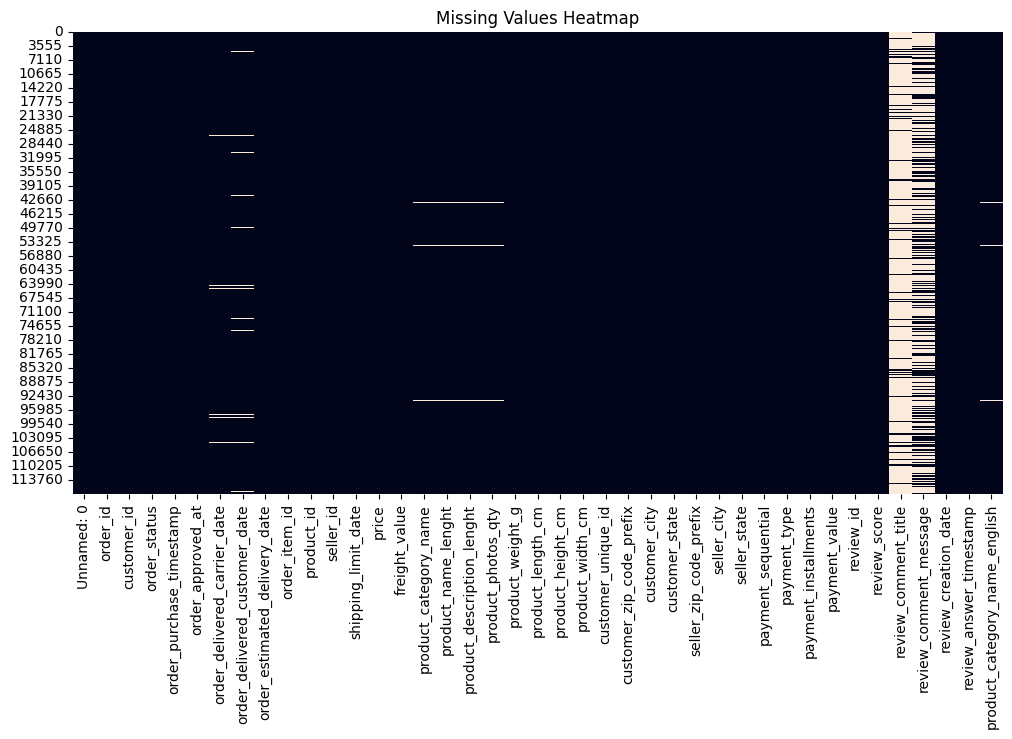

In [6]:
#Missing values analysis
import seaborn as sns
import matplotlib.pyplot as plt

# Count missing values
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

# Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

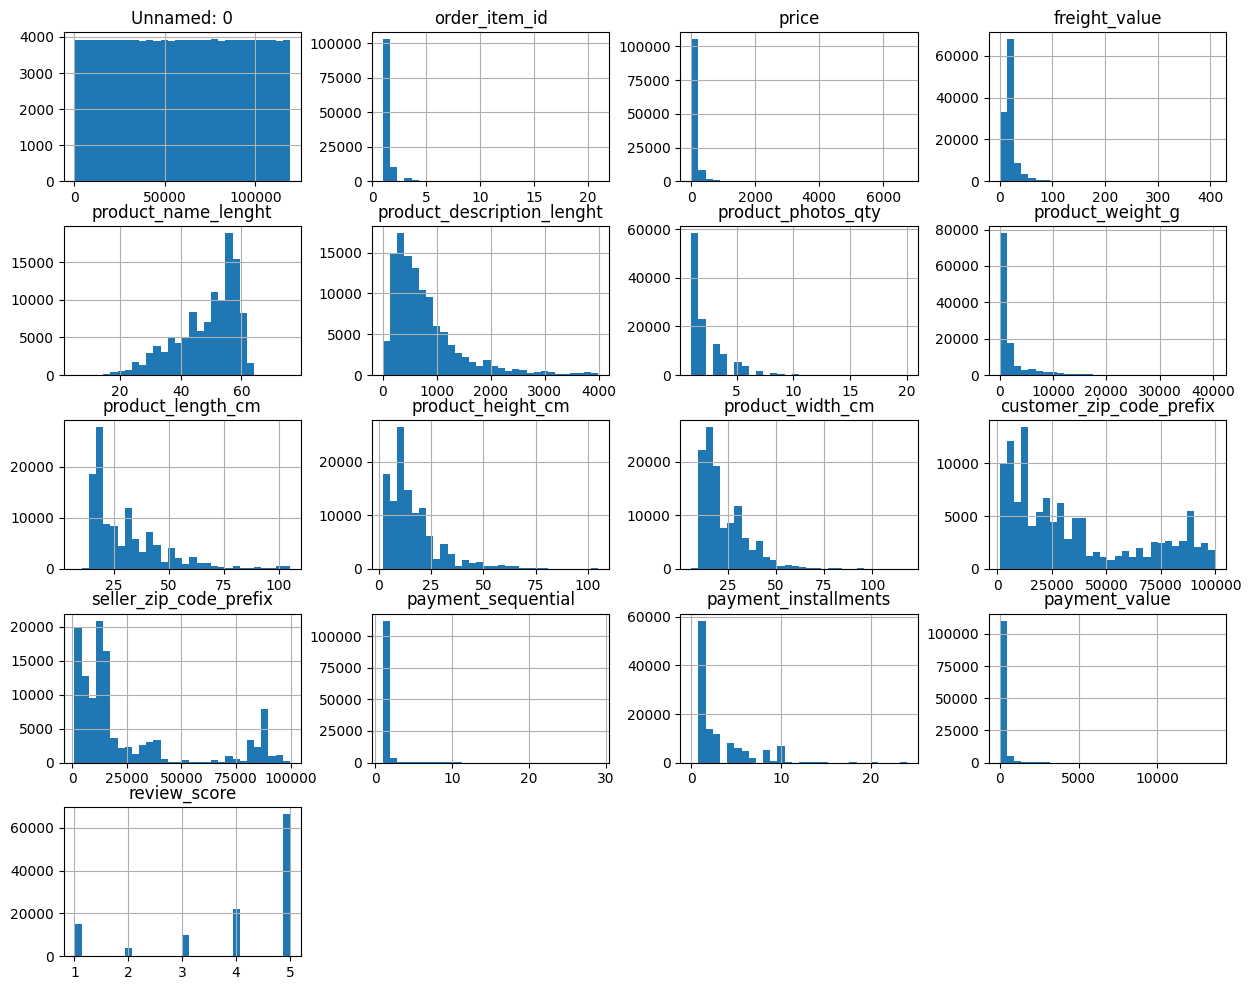

In [7]:
#Numeric features (univariate analysis)
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

df[numeric_cols].hist(figsize=(15,12), bins=30)
plt.show()

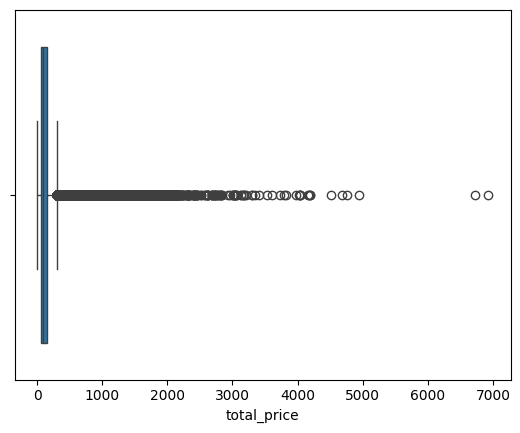

In [8]:
#Boxplot for outliers (feature engg)
# Total price (price + freight)
df['total_price'] = df['price'] + df['freight_value']
sns.boxplot(x=df["total_price"])
plt.show()

In [9]:
#delievery timein days
df['delivery_time'] = (pd.to_datetime(df['order_delivered_customer_date']) - 
                       pd.to_datetime(df['order_purchase_timestamp'])).dt.days
print(df['delivery_time'])

0          8.0
1          8.0
2          8.0
3         13.0
4          9.0
          ... 
117289    22.0
117290    24.0
117291    17.0
117292    17.0
117293     7.0
Name: delivery_time, Length: 117294, dtype: float64


In [10]:
# Sentiment from review_score (for classification later)
df['sentiment'] = df['review_score'].apply(lambda x: 1 if x >= 4 else 0)
print(df['sentiment'])
# Review length
df['review_length'] = df['review_comment_message'].dropna().apply(lambda x: len(str(x).split()))
print(df['review_length'])


0         1
1         1
2         1
3         1
4         1
         ..
117289    1
117290    1
117291    0
117292    0
117293    1
Name: sentiment, Length: 117294, dtype: int64
0         32.0
1         32.0
2         32.0
3          4.0
4          NaN
          ... 
117289    10.0
117290     5.0
117291     9.0
117292     9.0
117293     NaN
Name: review_length, Length: 117294, dtype: float64


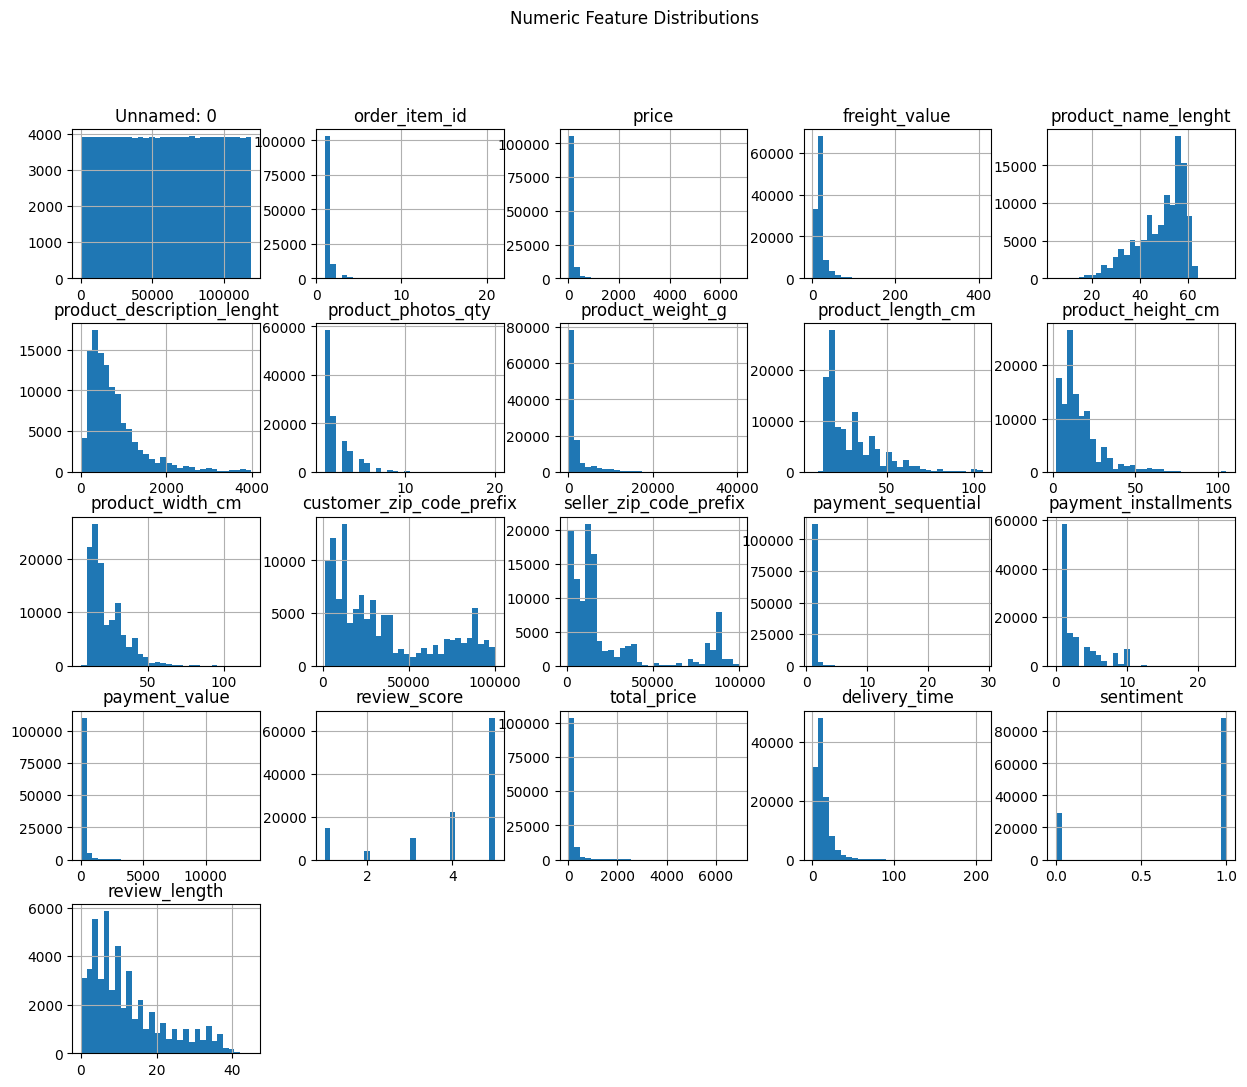

In [11]:
#Univariate analysis
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Numeric Histograms
df[numeric_cols].hist(figsize=(15,12), bins=30)
plt.suptitle("Numeric Feature Distributions")
plt.show()


Top 10 values for order_id:
order_id
895ab968e7bb0d5659d16cd74cd1650c    63
fedcd9f7ccdc8cba3a18defedd1a5547    38
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
465c2e1bee4561cb39e0db8c5993aafc    24
68986e4324f6a21481df4e6e89abcf01    24
a3725dfe487d359b5be08cac48b64ec5    24
6d58638e32674bebee793a47ac4cbadc    24
c6492b842ac190db807c15aff21a7dd6    24
285c2e15bebd4ac83635ccc563dc71f4    22
Name: count, dtype: int64


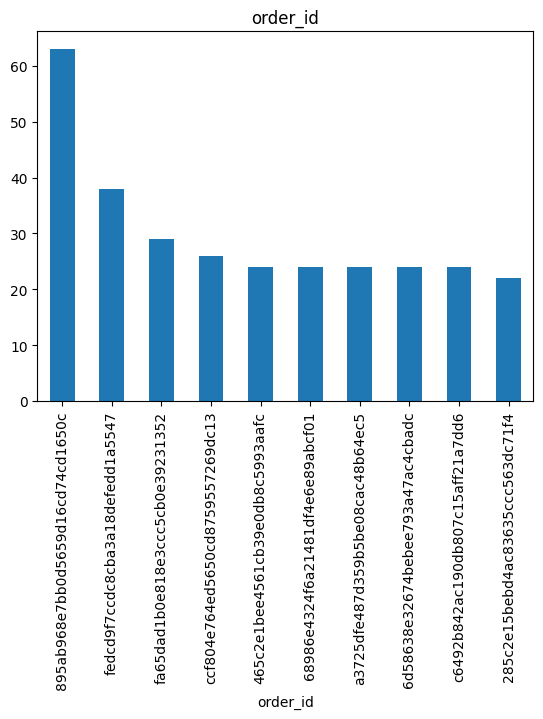


Top 10 values for customer_id:
customer_id
270c23a11d024a44c896d1894b261a83    63
13aa59158da63ba0e93ec6ac2c07aacb    38
9af2372a1e49340278e7c1ef8d749f34    29
92cd3ec6e2d643d4ebd0e3d6238f69e2    26
63b964e79dee32a3587651701a2b8dbf    24
86cc80fef09f7f39df4b0dbce48e81cb    24
d22f25a9fadfb1abbc2e29395b1239f4    24
2ba91e12e5e4c9f56b82b86d9031d329    24
6ee2f17e3b6c33d6a9557f280edd2925    24
b246eeed30b362c09d867b9e598bee51    22
Name: count, dtype: int64


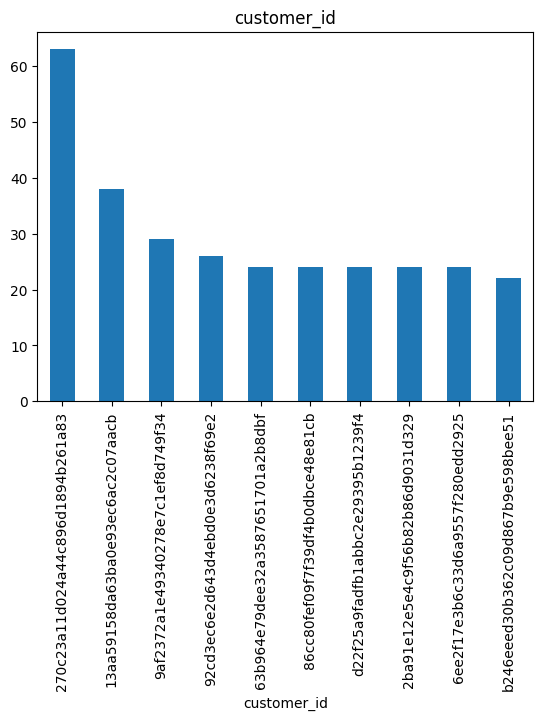


Top 10 values for order_status:
order_status
delivered      114824
shipped          1167
canceled          553
invoiced          370
processing        370
unavailable         7
approved            3
Name: count, dtype: int64


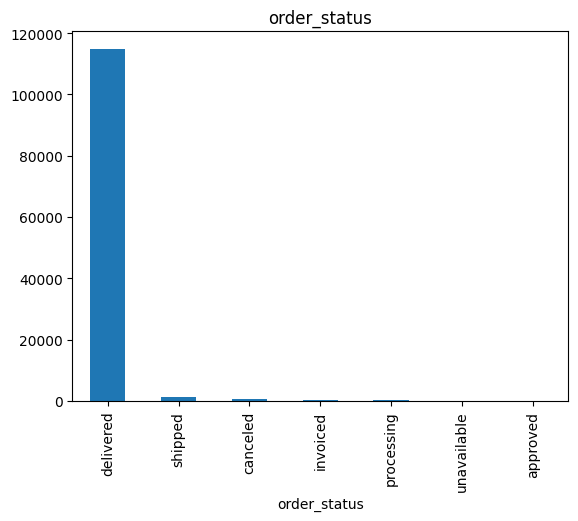


Top 10 values for order_purchase_timestamp:
order_purchase_timestamp
2017-08-08 20:26:31    63
2017-09-23 14:56:45    38
2017-04-20 12:45:34    29
2017-06-07 12:05:10    26
2017-11-25 13:54:39    24
2018-05-12 12:28:58    24
2018-02-14 16:34:27    24
2017-03-09 23:39:26    24
2017-07-07 14:55:43    24
2017-10-17 13:06:29    22
Name: count, dtype: int64


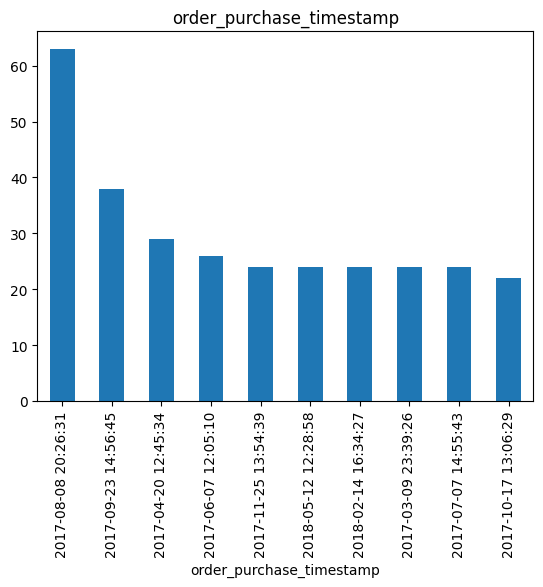


Top 10 values for order_approved_at:
order_approved_at
2017-08-08 20:43:31    63
2017-09-25 17:44:41    38
2017-04-22 09:10:13    29
2017-06-09 16:15:08    26
2018-02-21 12:28:15    24
2017-03-09 23:39:26    24
2017-07-07 15:10:17    24
2017-11-25 14:16:34    24
2018-05-12 15:41:58    24
2018-02-24 03:20:27    23
Name: count, dtype: int64


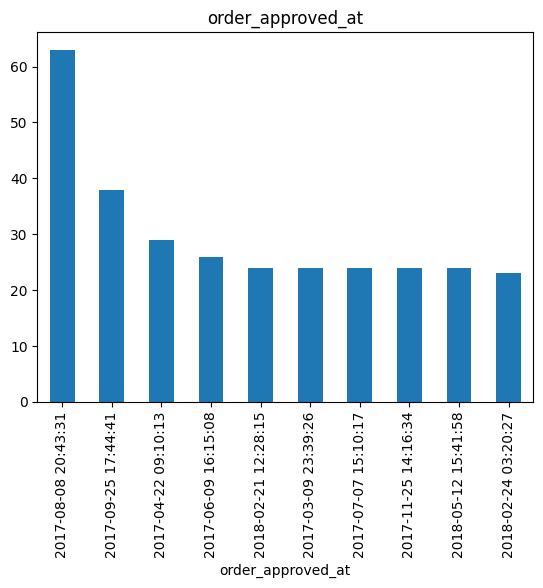


Top 10 values for order_delivered_carrier_date:
order_delivered_carrier_date
2017-08-10 11:58:14    63
2018-05-09 15:48:00    48
2017-10-02 23:47:54    38
2018-05-10 18:29:00    36
2018-05-14 14:25:00    32
2017-04-24 11:31:17    29
2018-05-04 15:46:00    29
2018-08-08 15:01:00    27
2017-06-16 15:50:28    26
2017-07-10 13:59:43    24
Name: count, dtype: int64


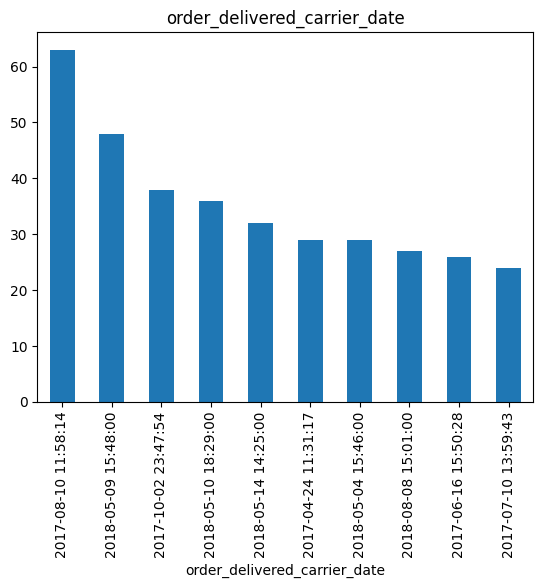


Top 10 values for order_delivered_customer_date:
order_delivered_customer_date
2017-08-14 12:46:18    63
2017-10-18 22:35:50    38
2017-06-22 16:04:46    26
2017-07-27 20:52:15    24
2017-03-21 13:32:45    24
2018-06-01 15:18:45    24
2018-02-28 20:09:19    24
2017-11-30 14:59:18    24
2017-10-22 14:43:54    22
2017-12-21 16:33:10    22
Name: count, dtype: int64


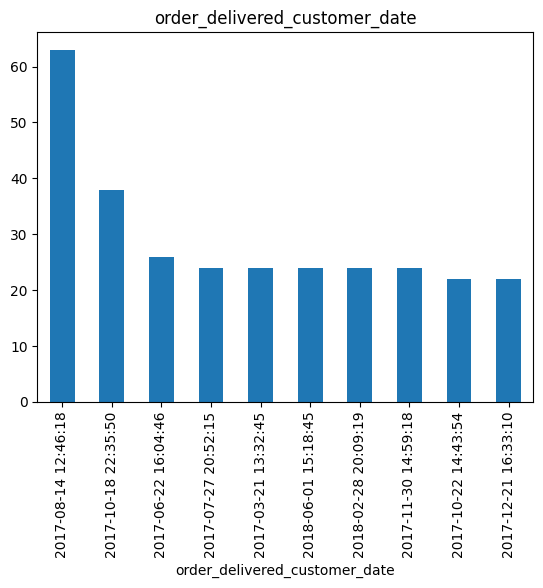


Top 10 values for order_estimated_delivery_date:
order_estimated_delivery_date
2017-12-20 00:00:00    652
2018-03-13 00:00:00    612
2018-03-12 00:00:00    610
2018-05-29 00:00:00    601
2018-07-16 00:00:00    589
2018-07-05 00:00:00    588
2018-05-28 00:00:00    582
2017-12-19 00:00:00    580
2018-05-30 00:00:00    580
2018-02-14 00:00:00    577
Name: count, dtype: int64


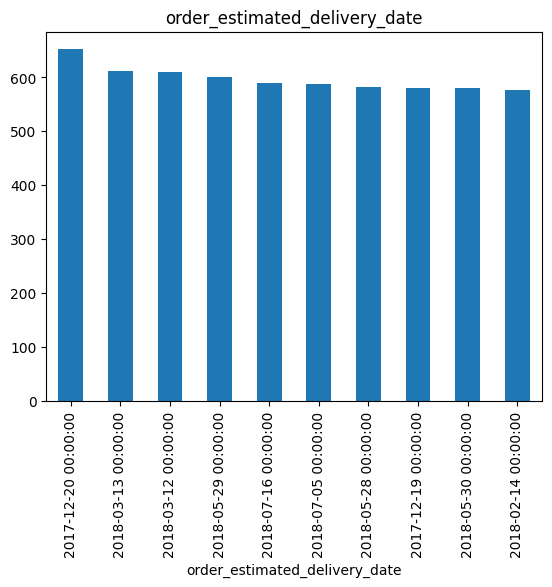


Top 10 values for product_id:
product_id
aca2eb7d00ea1a7b8ebd4e68314663af    533
99a4788cb24856965c36a24e339b6058    517
422879e10f46682990de24d770e7f83d    507
389d119b48cf3043d311335e499d9c6b    405
368c6c730842d78016ad823897a372db    395
53759a2ecddad2bb87a079a1f1519f73    389
d1c427060a0f73f6b889a5c7c61f2ac4    354
53b36df67ebb7c41585e8d54d6772e08    324
154e7e31ebfa092203795c972e5804a6    294
3dd2a17168ec895c781a9191c1e95ad7    276
Name: count, dtype: int64


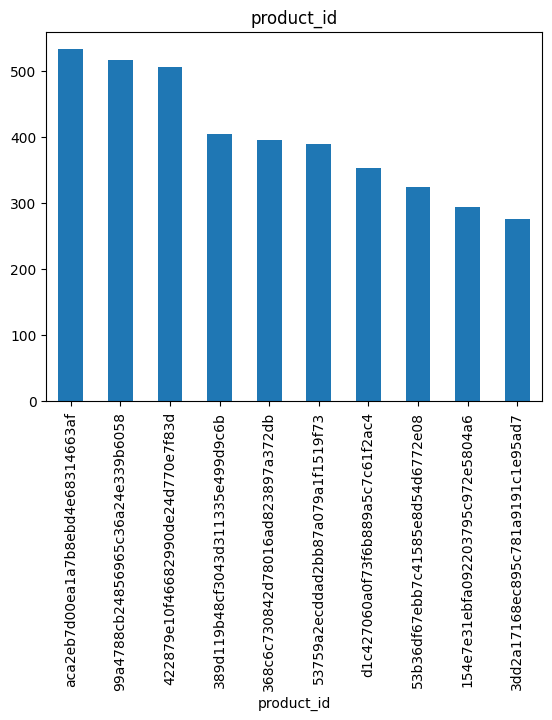


Top 10 values for seller_id:
seller_id
4a3ca9315b744ce9f8e9374361493884    2128
6560211a19b47992c3666cc44a7e94c0    2111
1f50f920176fa81dab994f9023523100    2009
cc419e0650a3c5ba77189a1882b7556a    1885
da8622b14eb17ae2831f4ac5b9dab84a    1656
955fee9216a65b617aa5c0531780ce60    1517
1025f0e2d44d7041d6cf58b6550e0bfa    1465
7c67e1448b00f6e969d365cea6b010ab    1454
7a67c85e85bb2ce8582c35f2203ad736    1233
ea8482cd71df3c1969d7b9473ff13abc    1233
Name: count, dtype: int64


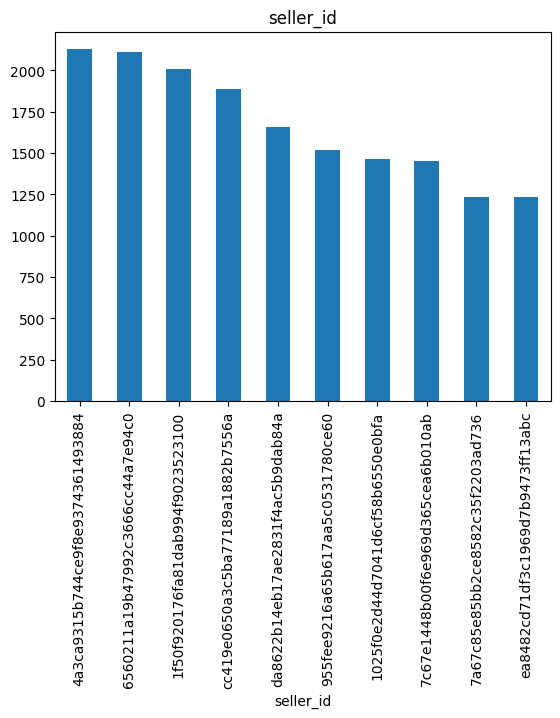


Top 10 values for shipping_limit_date:
shipping_limit_date
2017-08-14 20:43:31    63
2017-10-05 17:44:41    38
2017-04-27 09:10:13    29
2017-06-15 16:15:08    26
2018-05-15 15:30:28    24
2018-02-27 12:28:15    24
2017-07-13 15:10:17    24
2017-11-30 14:16:34    24
2017-03-15 23:39:26    24
2017-10-24 13:06:21    22
Name: count, dtype: int64


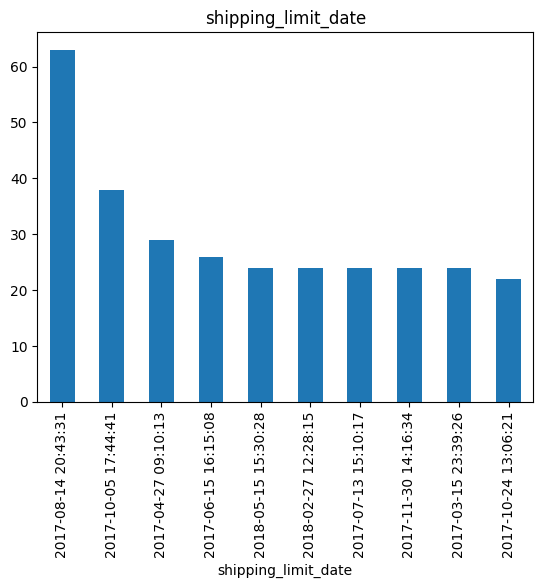


Top 10 values for product_category_name:
product_category_name
cama_mesa_banho           11846
beleza_saude               9944
esporte_lazer              8940
moveis_decoracao           8740
informatica_acessorios     8105
utilidades_domesticas      7331
relogios_presentes         6161
telefonia                  4690
ferramentas_jardim         4557
automotivo                 4356
Name: count, dtype: int64


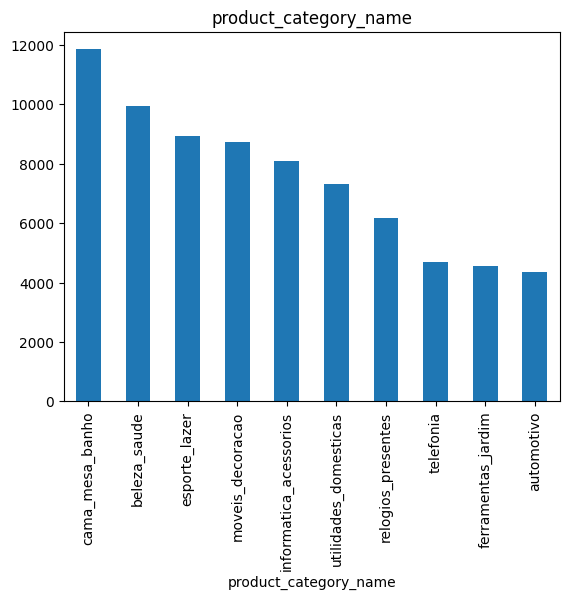


Top 10 values for customer_unique_id:
customer_unique_id
9a736b248f67d166d2fbb006bcb877c3    75
6fbc7cdadbb522125f4b27ae9dee4060    38
f9ae226291893fda10af7965268fb7f6    35
8af7ac63b2efbcbd88e5b11505e8098a    29
569aa12b73b5f7edeaa6f2a01603e381    26
1d2435aa3b858d45c707c9fc25e18779    24
85963fd37bfd387aa6d915d8a1065486    24
90807fdb59eec2152bc977feeb6e47e7    24
5419a7c9b86a43d8140e2939cd2c2f7e    24
d97b3cfb22b0d6b25ac9ed4e9c2d481b    24
Name: count, dtype: int64


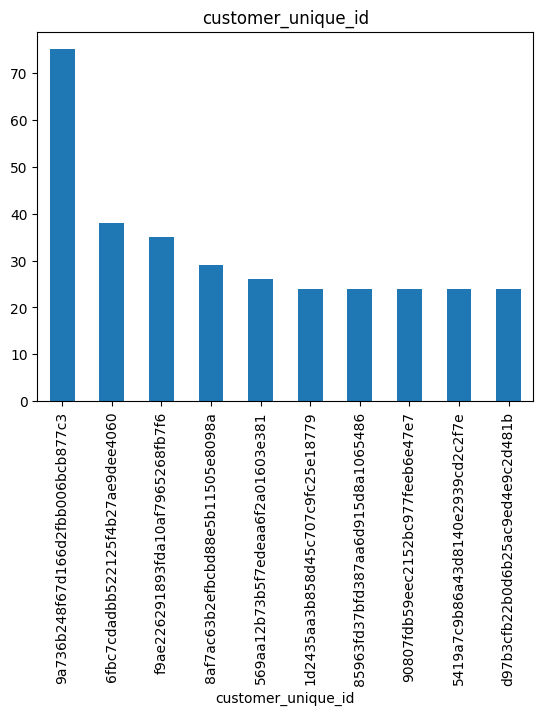


Top 10 values for customer_city:
customer_city
sao paulo                18580
rio de janeiro            8155
belo horizonte            3251
brasilia                  2465
curitiba                  1807
campinas                  1723
porto alegre              1655
salvador                  1507
guarulhos                 1386
sao bernardo do campo     1119
Name: count, dtype: int64


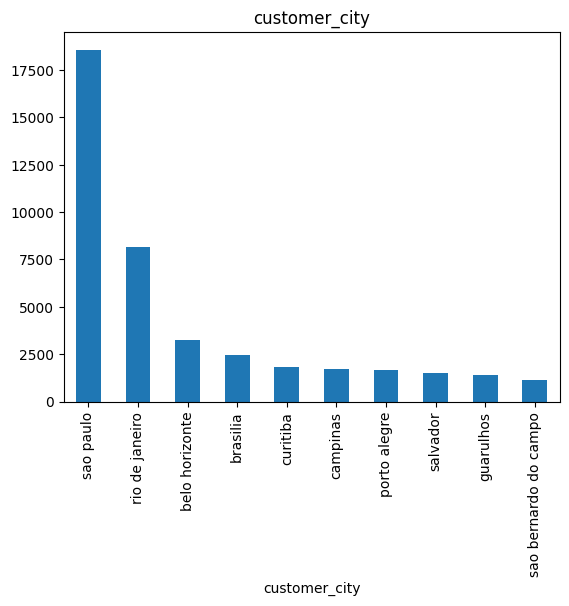


Top 10 values for customer_state:
customer_state
SP    49518
RJ    15216
MG    13610
RS     6511
PR     5956
SC     4280
BA     4014
DF     2481
GO     2416
ES     2319
Name: count, dtype: int64


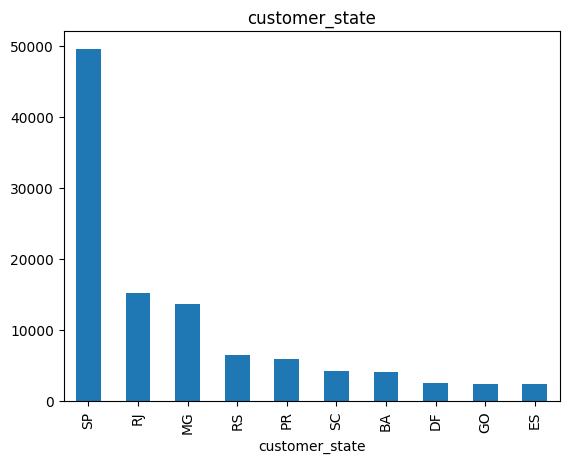


Top 10 values for seller_city:
seller_city
sao paulo                29043
ibitinga                  8267
curitiba                  3144
santo andre               3134
sao jose do rio preto     2673
belo horizonte            2663
rio de janeiro            2519
guarulhos                 2441
ribeirao preto            2357
maringa                   2281
Name: count, dtype: int64


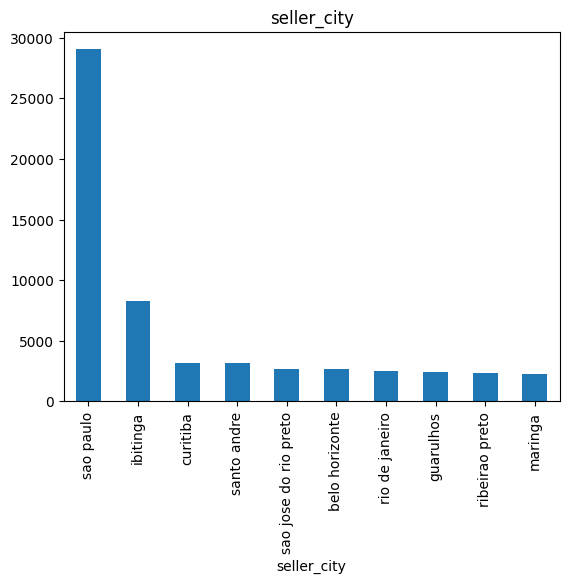


Top 10 values for seller_state:
seller_state
SP    83639
MG     9228
PR     9027
RJ     4991
SC     4239
RS     2272
DF      948
BA      698
GO      547
PE      461
Name: count, dtype: int64


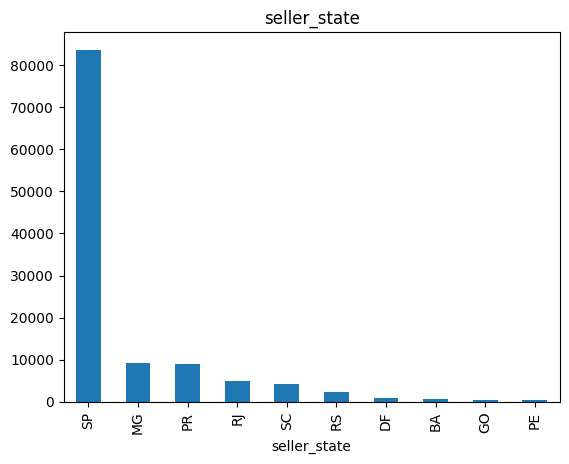


Top 10 values for payment_type:
payment_type
credit_card    86506
boleto         22816
voucher         6280
debit_card      1692
Name: count, dtype: int64


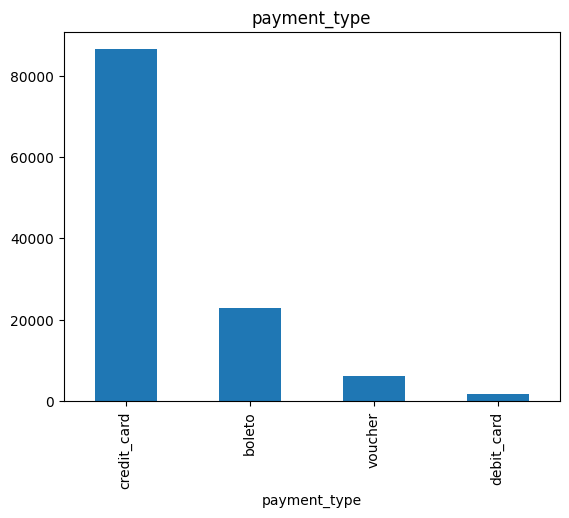


Top 10 values for review_id:
review_id
eef5dbca8d37dfce6db7d7b16dd0525e    63
7145a6f0d38ec713897856cbdcfcdb7f    38
f28281373ab8815bafafe371218f02ce    29
8823bba1e3301fee652eb06de8ef9435    26
b0c2f8c122ebef9f77753f7d167cf634    24
b79b22bb50f78f1afe361661011fd892    24
cc074f1c33940c4f0dd904705f98e39e    24
b5292206f96cd5d97359940203a0b510    24
7e568736c98c553aea896a5dca746d5a    22
8fb71ed887db39231871ef3d1ba781cf    21
Name: count, dtype: int64


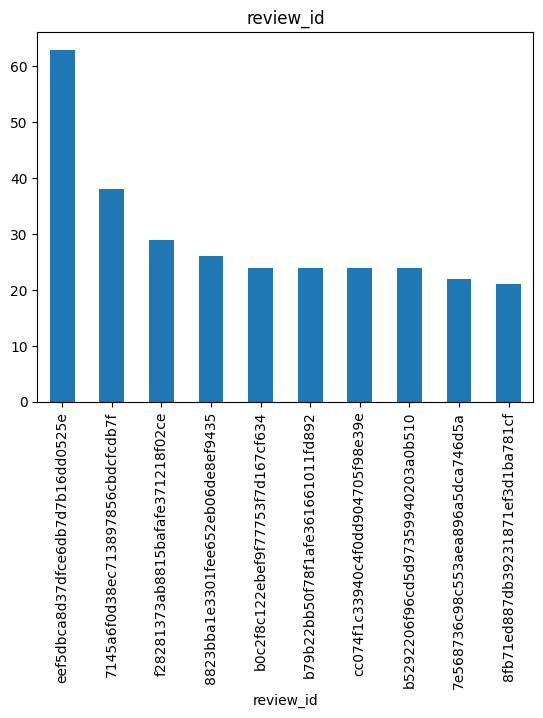


Top 10 values for review_comment_title:
review_comment_title
Recomendo          494
recomendo          403
Bom                331
super recomendo    310
Excelente          293
Muito bom          279
Ótimo              268
Super recomendo    256
Ótimo              238
Otimo              201
Name: count, dtype: int64


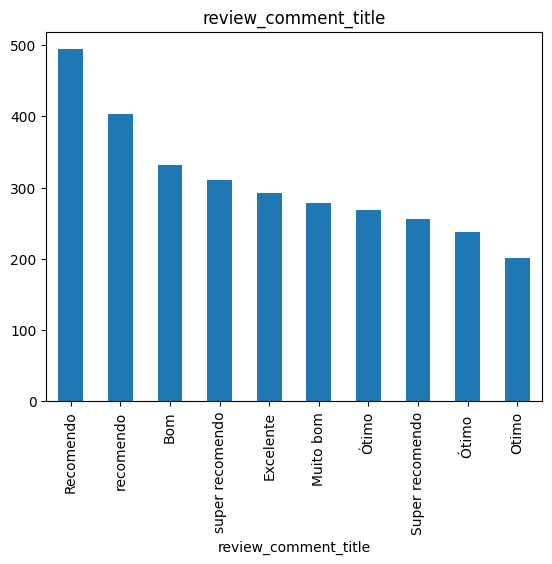


Top 10 values for review_comment_message:
review_comment_message
Muito bom    259
Bom          207
muito bom    137
bom          118
Otimo        116
Recomendo    111
otimo        103
Ok            87
Ótimo         86
Ótimo         85
Name: count, dtype: int64


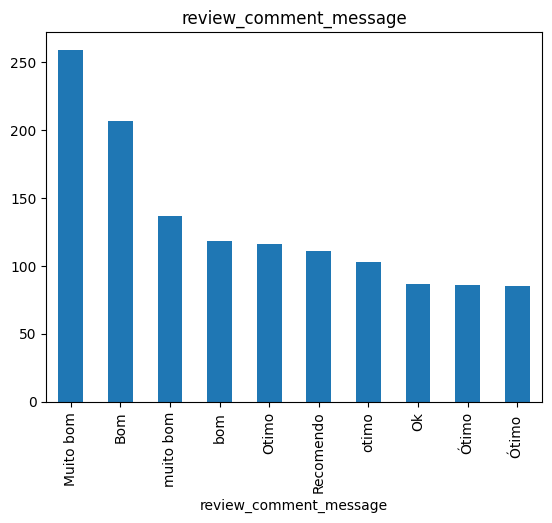


Top 10 values for review_creation_date:
review_creation_date
2017-12-19 00:00:00    542
2018-05-22 00:00:00    521
2018-05-15 00:00:00    517
2018-05-19 00:00:00    509
2017-12-20 00:00:00    509
2018-05-04 00:00:00    504
2018-08-28 00:00:00    504
2018-03-29 00:00:00    500
2018-04-12 00:00:00    483
2018-03-30 00:00:00    482
Name: count, dtype: int64


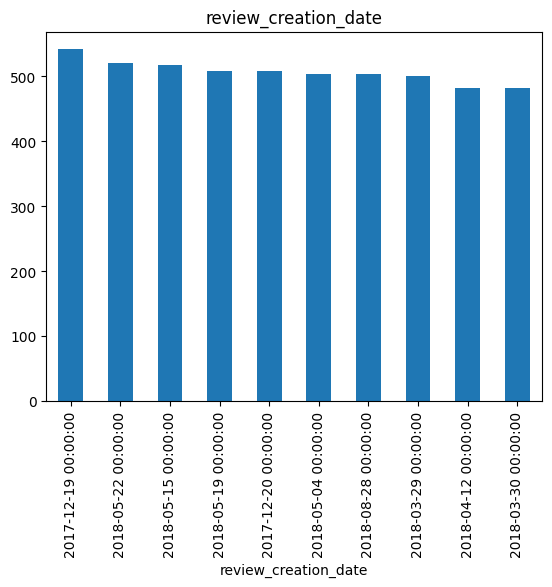


Top 10 values for review_answer_timestamp:
review_answer_timestamp
2017-08-17 22:17:55    63
2017-10-19 21:08:44    38
2017-05-24 16:21:27    29
2017-06-28 18:49:50    26
2018-03-07 15:08:10    24
2017-03-23 08:34:13    24
2018-06-04 19:04:20    24
2017-08-01 13:20:31    24
2017-12-22 20:33:52    22
2017-07-30 14:19:07    21
Name: count, dtype: int64


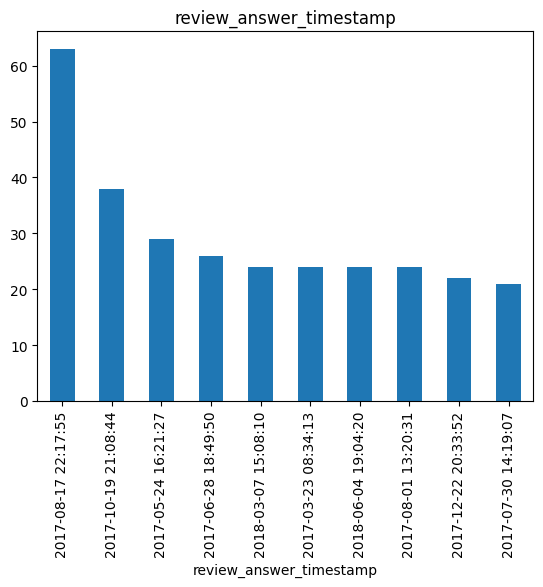


Top 10 values for product_category_name_english:
product_category_name_english
bed_bath_table           11846
health_beauty             9944
sports_leisure            8940
furniture_decor           8740
computers_accessories     8105
housewares                7331
watches_gifts             6161
telephony                 4690
garden_tools              4557
auto                      4356
Name: count, dtype: int64


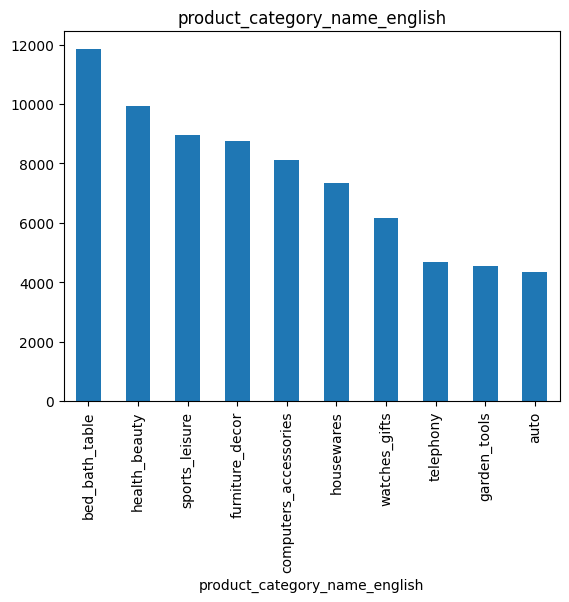

In [12]:
# Categorical Counts
for col in categorical_cols:
    print(f"\nTop 10 values for {col}:")
    print(df[col].value_counts().head(10))
    df[col].value_counts().head(10).plot(kind='bar', title=col)
    plt.show()


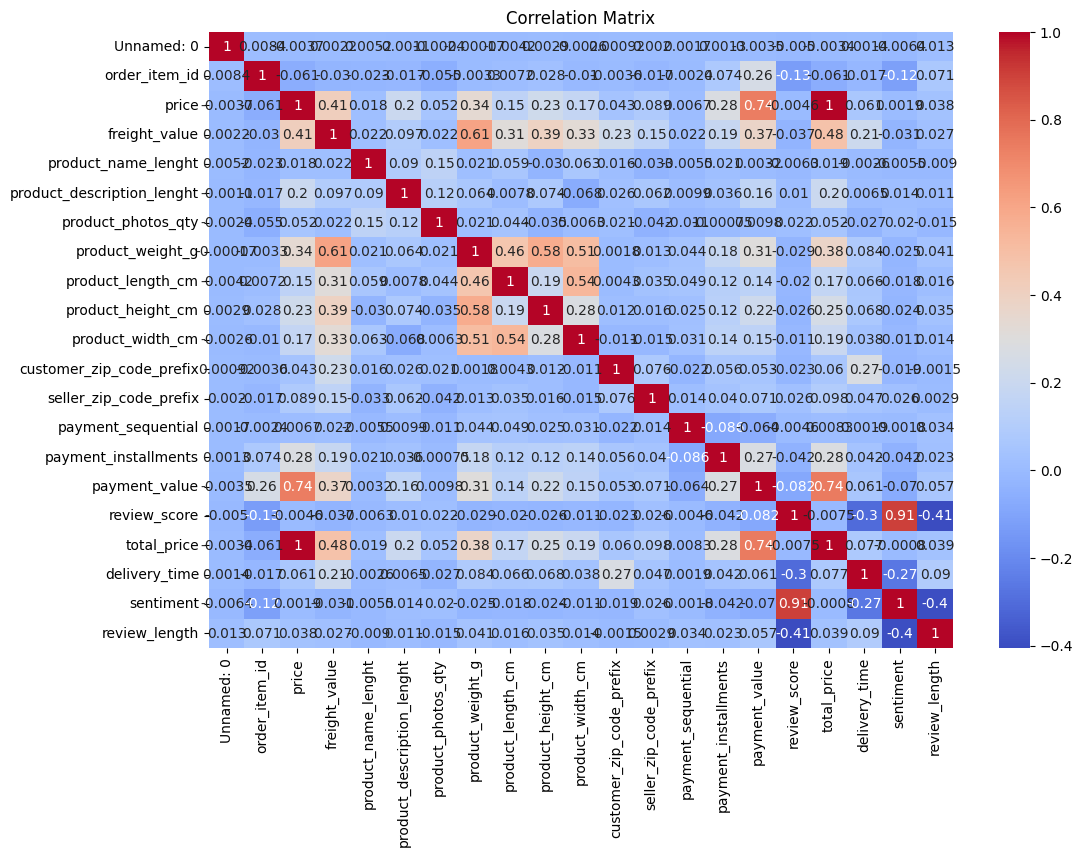

In [13]:
#BIVARIATE ANALYSIS
# Correlation Matrix
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

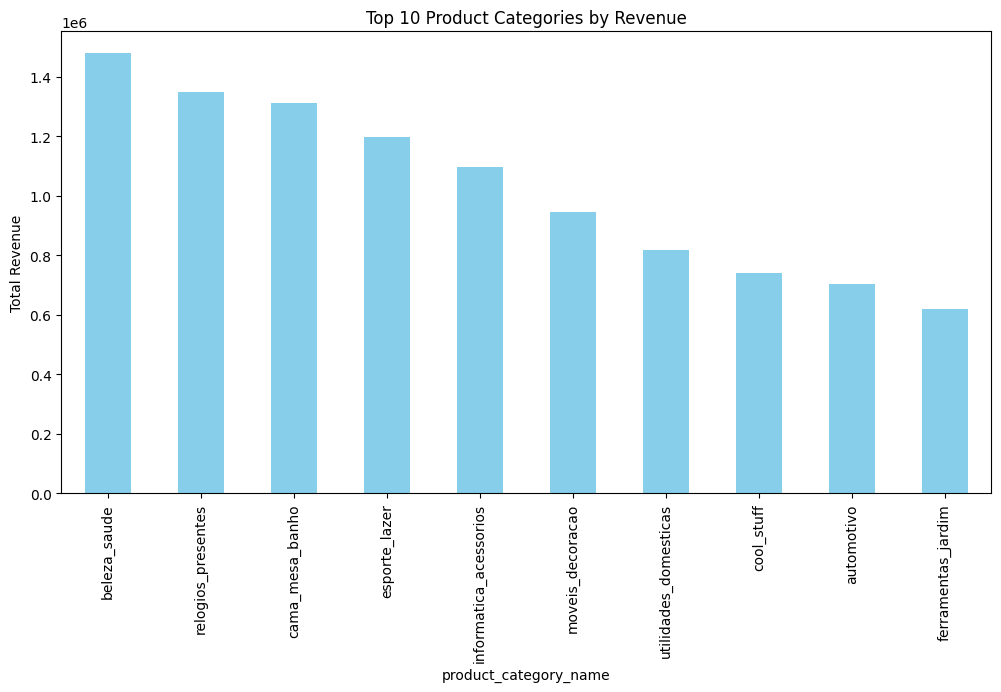

In [14]:
# Total Price vs Product Category
top_categories = df.groupby("product_category_name")['total_price'].sum().sort_values(ascending=False).head(10)
top_categories.plot(kind='bar', figsize=(12,6), color='skyblue')
plt.title("Top 10 Product Categories by Revenue")
plt.ylabel("Total Revenue")
plt.show()

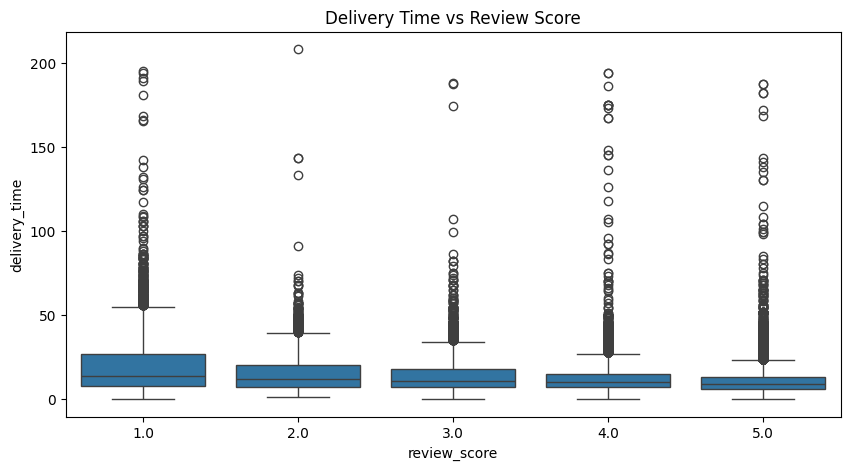

In [15]:
# Delivery Time vs Review Score
plt.figure(figsize=(10,5))
sns.boxplot(x='review_score', y='delivery_time', data=df)
plt.title("Delivery Time vs Review Score")
plt.show()

0 rows could not be converted


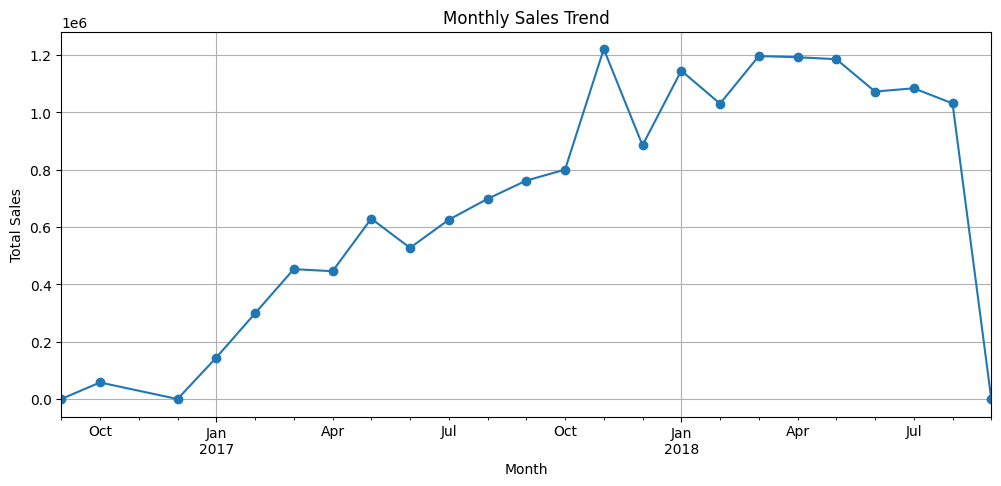

In [ ]:
#time series analysis
import pandas as pd
import matplotlib.pyplot as plt

# Force conversion to datetime
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'], errors='coerce')

# Check for any rows that failed conversion
print(df['order_purchase_timestamp'].isnull().sum(), "rows could not be converted")

# Drop rows with invalid dates (if any)
df = df.dropna(subset=['order_purchase_timestamp'])

# Group by month and sum total_price
monthly_sales = df.groupby(df['order_purchase_timestamp'].dt.to_period('M'))['total_price'].sum()

# Plot
monthly_sales.plot(figsize=(12,5), marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

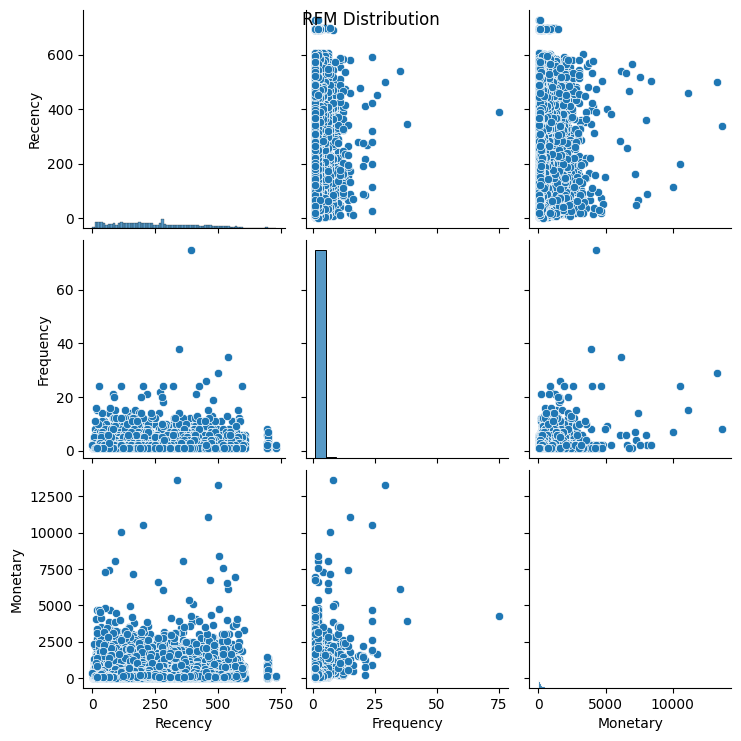

In [17]:
#Customer Segmentation (RFM Prep)
snapshot_date = df['order_purchase_timestamp'].max()
rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'count',
    'total_price': 'sum'
})
rfm.columns = ['Recency','Frequency','Monetary']

sns.pairplot(rfm)
plt.suptitle("RFM Distribution")
plt.show()

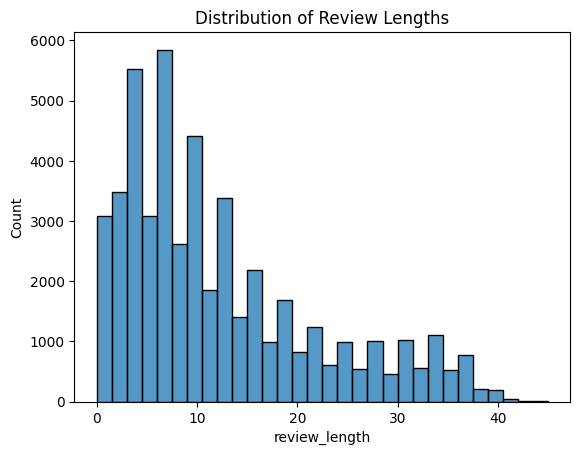

In [18]:
#Review Analysis (NLP Prep)
# Distribution of Review Length
sns.histplot(df['review_length'].dropna(), bins=30)
plt.title("Distribution of Review Lengths")
plt.show()

In [19]:
# Most common words in reviews
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
words = " ".join(df['review_comment_message'].dropna().astype(str)).lower()
words = re.findall(r'\w+', words)
most_common_words = Counter(words).most_common(20)
print("\nTop 20 Most Common Words in Reviews:")
for word, count in most_common_words:
    print(word, count)


Top 20 Most Common Words in Reviews:
o 22616
produto 21117
e 20207
a 15092
de 14352
não 13060
do 12985
que 10337
prazo 9625
muito 9169
entrega 7613
recebi 7504
com 6963
chegou 6593
antes 6318
no 6110
um 5951
foi 5811
é 5411
bom 5342


In [20]:
#Outlier Detection
Q1 = df['total_price'].quantile(0.25)
Q3 = df['total_price'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['total_price'] < Q1 - 1.5*IQR) | (df['total_price'] > Q3 + 1.5*IQR)]
print("\nNumber of outliers in total_price:", len(outliers))



Number of outliers in total_price: 8663


In [21]:
#SUMMARY
print("Key EDA Insights")
print(f"Top product categories: {list(top_categories.index)}")
print(f"Average delivery time (days): {df['delivery_time'].mean():.2f}")
print(f"Average review score: {df['review_score'].mean():.2f}")
print(f"Percentage of positive reviews: {(df['sentiment'].sum()/len(df))*100:.2f}%")
print(f"Number of unique customers: {df['customer_unique_id'].nunique()}")
print(f"Number of unique products: {df['product_id'].nunique()}")

Key EDA Insights
Top product categories: ['beleza_saude', 'relogios_presentes', 'cama_mesa_banho', 'esporte_lazer', 'informatica_acessorios', 'moveis_decoracao', 'utilidades_domesticas', 'cool_stuff', 'automotivo', 'ferramentas_jardim']
Average delivery time (days): 11.98
Average review score: 4.03
Percentage of positive reviews: 75.47%
Number of unique customers: 94694
Number of unique products: 32784


In [22]:
# Count how many orders are canceled, delivered, shipped, etc.
df['order_status'].value_counts()

order_status
delivered      114824
shipped          1167
canceled          553
invoiced          370
processing        370
unavailable         7
approved            3
Name: count, dtype: int64